# Logistic regression

This notebook implements logistic regression with three different approaches:
1. Scikit-learn
2. PyTorch
3. Gradient descent (without using a framework)

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import random_split, TensorDataset, DataLoader

### Create synthetic dataset

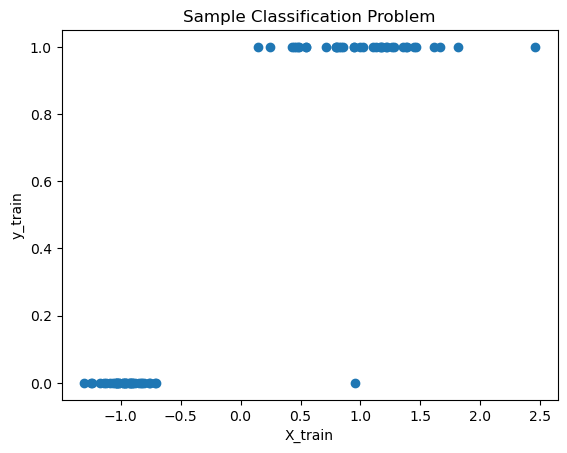

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

fig, ax = plt.subplots()
ax.scatter(X_train, y_train)
ax.set_xlabel("X_train")
ax.set_ylabel("y_train")
ax.set_title("Sample Classification Problem")
plt.show()

### 1. Scikit-learn

In [3]:
sklearn_model = LogisticRegression()
sklearn_model.fit(X_train, y_train)
y_pred_train = sklearn_model.predict(X_test)

print(f"Parameters: {sklearn_model.intercept_.item()}, {sklearn_model.coef_.item()}")
print()
print(classification_report(y_test, y_pred_train))

Parameters: 0.05063274087705363, 2.9483325237044427

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        11

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



### 2. PyTorch

In [4]:
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

dataset = TensorDataset(
    torch.from_numpy(X.astype("float32")),
    torch.from_numpy(y.astype("float32")).unsqueeze(1)
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=8, shuffle=True)

pytorch_model = LogisticRegressionModel()
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(pytorch_model.parameters(), lr=0.1)
pytorch_train_losses = []
pytorch_test_losses = []

In [5]:
def train():
    pytorch_model.train()
    train_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        y_pred = pytorch_model(X)
        loss = criterion(y_pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    average_loss = train_loss / len(train_loader)
    pytorch_train_losses.append(average_loss)
    print(f"Training loss = {average_loss:.2f}")

def test():
    pytorch_model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in test_loader:
            y_pred = pytorch_model(X)
            loss = criterion(y_pred, y)
            test_loss += loss.item()
        average_loss = test_loss / len(test_loader)
        pytorch_test_losses.append(average_loss)
        print(f"Testing loss = {average_loss:.2f}")


In [6]:
epochs = 20
for epoch in range(epochs):
    print(f"Epoch {epoch}/{epochs}")
    train()
    test()
    print()

Epoch 0/20
Training loss = 0.85
Testing loss = 0.63

Epoch 1/20
Training loss = 0.61
Testing loss = 0.46

Epoch 2/20
Training loss = 0.47
Testing loss = 0.35

Epoch 3/20
Training loss = 0.37
Testing loss = 0.30

Epoch 4/20
Training loss = 0.31
Testing loss = 0.27

Epoch 5/20
Training loss = 0.27
Testing loss = 0.23

Epoch 6/20
Training loss = 0.24
Testing loss = 0.19

Epoch 7/20
Training loss = 0.22
Testing loss = 0.19

Epoch 8/20
Training loss = 0.21
Testing loss = 0.17

Epoch 9/20
Training loss = 0.19
Testing loss = 0.15

Epoch 10/20
Training loss = 0.18
Testing loss = 0.16

Epoch 11/20
Training loss = 0.17
Testing loss = 0.14

Epoch 12/20
Training loss = 0.16
Testing loss = 0.12

Epoch 13/20
Training loss = 0.16
Testing loss = 0.14

Epoch 14/20
Training loss = 0.15
Testing loss = 0.11

Epoch 15/20
Training loss = 0.15
Testing loss = 0.12

Epoch 16/20
Training loss = 0.14
Testing loss = 0.10

Epoch 17/20
Training loss = 0.14
Testing loss = 0.10

Epoch 18/20
Training loss = 0.14
Testi

### 3. Gradient descent

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def negative_log_likelihood(y_actual, y_predicted):
    return -(
        y_actual * np.log(y_predicted)
        + (1 - y_actual) * np.log(1 - y_predicted)
    )

def z(theta, X):
    return X @ theta[1:] + theta[0]

def log_loss(y_actual, y_predicted):
    return negative_log_likelihood(y_actual, y_predicted).mean()

gradient_descent_train_losses = []
gradient_descent_test_losses = []
learning_rate = 0.5
m = X_train.shape[0]
rng = np.random.default_rng()
theta = rng.random(size=2)
epochs = 200
for epoch in range(epochs):
    y_pred_train = sigmoid(z(theta, X_train))
    train_loss = log_loss(y_train, y_pred_train)
    gradient_descent_train_losses.append(train_loss)

    y_pred_test = sigmoid(z(theta, X_test))
    test_loss = log_loss(y_test, y_pred_test)
    gradient_descent_test_losses.append(test_loss)

    if epoch % 40 == 39:
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Parameters: {theta}")
        print(f"Training loss: {train_loss}")
        print(f"Testing loss: {test_loss}")
        print()

    # Calculate gradients and update weights
    theta[0] -= learning_rate / m * (y_pred_train - y_train).sum()
    theta[1:] = theta[1:] - learning_rate / m * X_train.transpose() @ (y_pred_train - y_train)

Epoch 40/200
Parameters: [0.03282951 2.75128552]
Training loss: 0.12369603417799543
Testing loss: 0.11545798302002938

Epoch 80/200
Parameters: [0.04987665 3.4184879 ]
Training loss: 0.10062157254270736
Testing loss: 0.08150893332181644

Epoch 120/200
Parameters: [0.06033752 3.78446879]
Training loss: 0.09383097875089125
Testing loss: 0.06866595596801262

Epoch 160/200
Parameters: [0.06376617 4.02384514]
Training loss: 0.09094554327485087
Testing loss: 0.06190939963952306

Epoch 200/200
Parameters: [0.0629412  4.19375078]
Training loss: 0.08949592161349125
Testing loss: 0.057801160147503514



In [8]:
y_pred_train = sigmoid(z(theta, X_test))
classifications = y_pred_train.round()
accuracy = (classifications == y_test).sum() / y_test.size
print(f"Testing accuracy: {accuracy}")

Testing accuracy: 1.0


### Visualize results

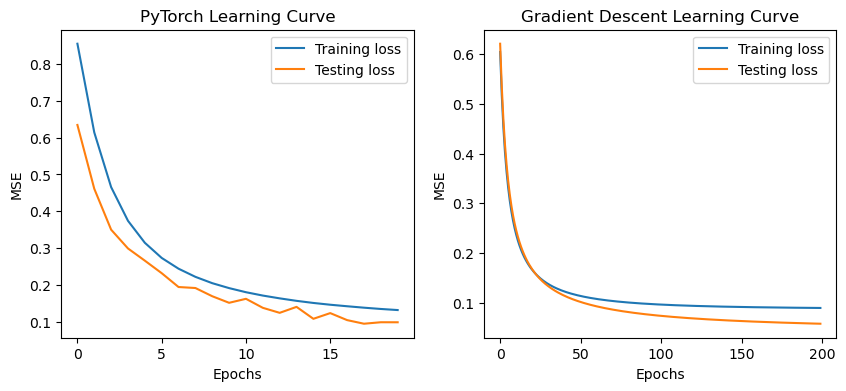

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_title("PyTorch Learning Curve")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MSE")
ax1.plot(pytorch_train_losses, label="Training loss")
ax1.plot(pytorch_test_losses, label="Testing loss")
ax1.legend()

ax2.set_title("Gradient Descent Learning Curve")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("MSE")
ax2.plot(gradient_descent_train_losses, label="Training loss")
ax2.plot(gradient_descent_test_losses, label="Testing loss")
ax2.legend()

plt.show()

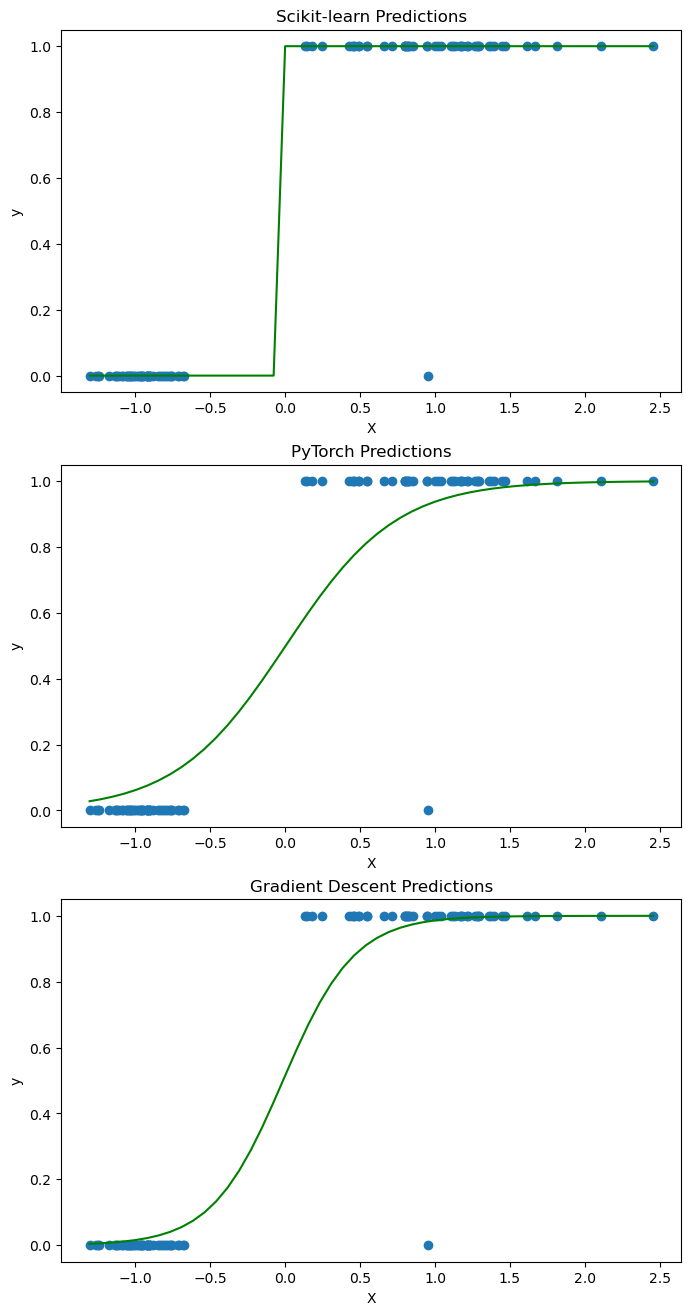

In [10]:
np_inputs = np.linspace(min(X), max(X))
torch_inputs = torch.from_numpy(np_inputs.astype("float32"))

pytorch_model.eval()
with torch.no_grad():
    sklearn_outputs = sklearn_model.predict(np_inputs)
    pytorch_outputs = pytorch_model(torch_inputs)
    gradient_descent_outputs = sigmoid(z(theta, np_inputs))

fig, axs = plt.subplots(3, 1, figsize=(8, 16))
axs[0].set_title("Scikit-learn Predictions")
axs[1].set_title("PyTorch Predictions")
axs[2].set_title("Gradient Descent Predictions")

axs[0].plot(np_inputs, sklearn_outputs, "g")
axs[1].plot(torch_inputs, pytorch_outputs, "g")
axs[2].plot(np_inputs, gradient_descent_outputs, "g")

for i in range(3):
    axs[i].set_xlabel("X")
    axs[i].set_ylabel("y")
    axs[i].scatter(X, y)

plt.show()